In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import warnings
warnings.filterwarnings("ignore")

nltk.download("vader_lexicon", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer

df = pd.read_csv("../data/processed/tiktok_clean.csv")
print(f"Shape: {df.shape}")

Shape: (658, 14)


In [9]:
# checking sentiment on every caption
sentanalyzer = SentimentIntensityAnalyzer()

df["sentiment"] = df["text_part"].apply(
    lambda x: sentanalyzer.polarity_scores(str(x))["compound"]
)

print("Sentiment scores added")
df[["text_part", "sentiment"]].head(10)

Sentiment scores added


,text_part,sentiment
0,А че такое?,0.0000
1,Таксист в шоке😱 Inst: Andrey_Pryahin,0.0000
2,"Учитесь хитрить, как она 😄😉",0.0000
3,телефонный пранк от говорящего ворона Карлушы,0.0000
4,Statement ✍️,0.0000
5,Monfils is the ultimate entertainer 🤩,0.3818
6,Nope 🙂‍↔️ 🎥 @★𝐌𝐚𝐫𝐢𝐖𝐨𝐫★,0.0000
7,Ed’s been a naughty boy so he has been arrested |,-0.4767
8,A man carrying a meat cleaver has been tackled...,-0.5423
9,Replying to @zahrocabasaxmed12 wakas👸🏻❤️ 🦋😋 👸🏻...,0.0000


In [10]:
# sentiment label
def label_sentiment(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment_label"] = df["sentiment"].apply(label_sentiment)
df["sentiment_label"].value_counts()

sentiment_label
neutral     465
positive    165
negative     28
Name: count, dtype: int64

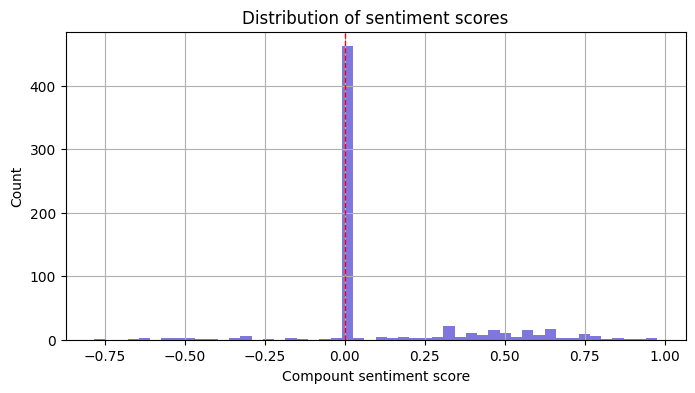

In [13]:
#sentiment distribution
df["sentiment"].hist(bins=50, figsize=(8, 4), color="#7F77DD")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.title("Distribution of sentiment scores")
plt.xlabel("Compount sentiment score")
plt.ylabel("Count")
plt.show()

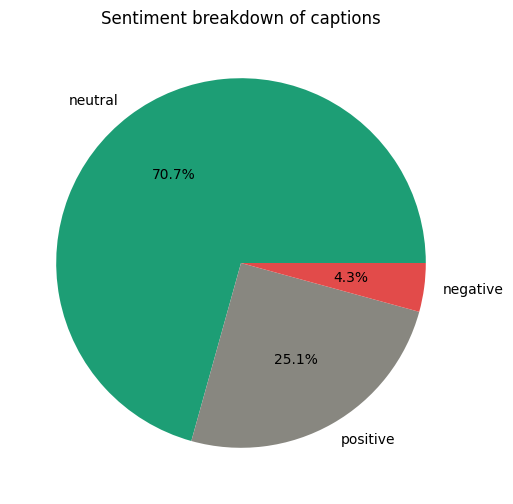

In [14]:
#pie breakdown of sentijment
df["sentiment_label"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", figsize=(6, 6),
    colors=["#1D9E75", "#888780", "#E24B4A"]
)
plt.title("Sentiment breakdown of captions")
plt.ylabel("")
plt.show()

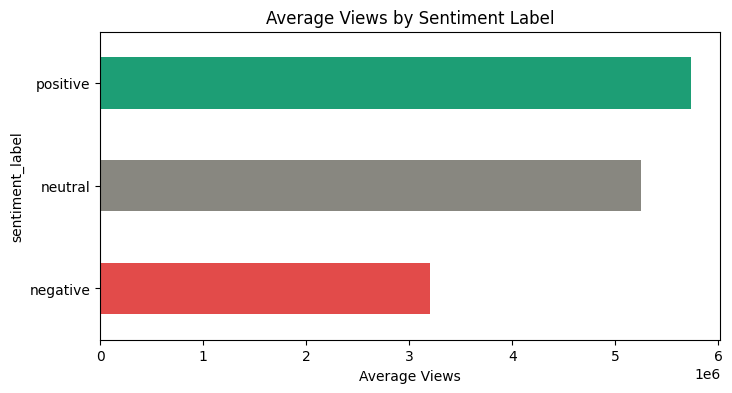

In [15]:
#visualize setiment affects views
df.groupby("sentiment_label")["views"].mean().sort_values().plot(
    kind="barh", figsize=(8, 4), color=["#E24B4A", "#888780", "#1D9E75"]
)
plt.title("Average Views by Sentiment Label")
plt.xlabel("Average Views")
plt.show()

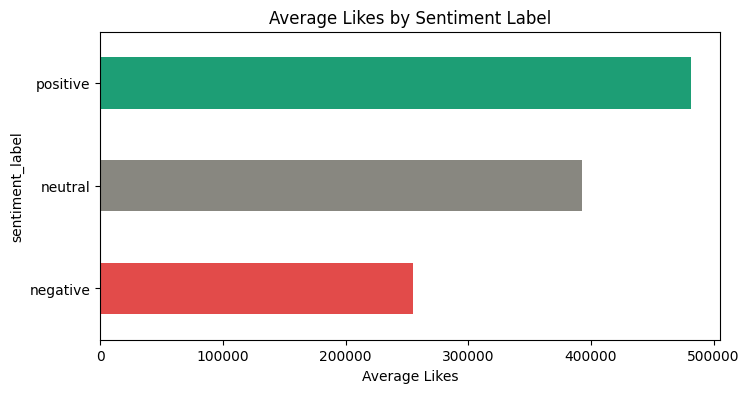

In [16]:
#visualize sentiment affects likes
df.groupby("sentiment_label")["likes"].mean().sort_values().plot(
    kind="barh", figsize=(8, 4), color=["#E24B4A", "#888780", "#1D9E75"]
)
plt.title("Average Likes by Sentiment Label")
plt.xlabel("Average Likes")
plt.show()

In [18]:
#check correlation of sentiment vs. views 
from scipy import stats

median_followers = df["author_followers"].median()
df["creator_tier"] = df["author_followers"].apply(
    lambda x: "high followers" if x >= median_followers else "low followers"
)

for tier in ["low followers", "high followers"]:
    subset = df[df["creator_tier"] == tier]
    r, p = stats.pearsonr(subset["sentiment"], subset["views"])
    print(f"{tier}: r= {r:.3f}, p= {p:.4f}")

low followers: r= 0.033, p= 0.5666
high followers: r= -0.010, p= 0.8497


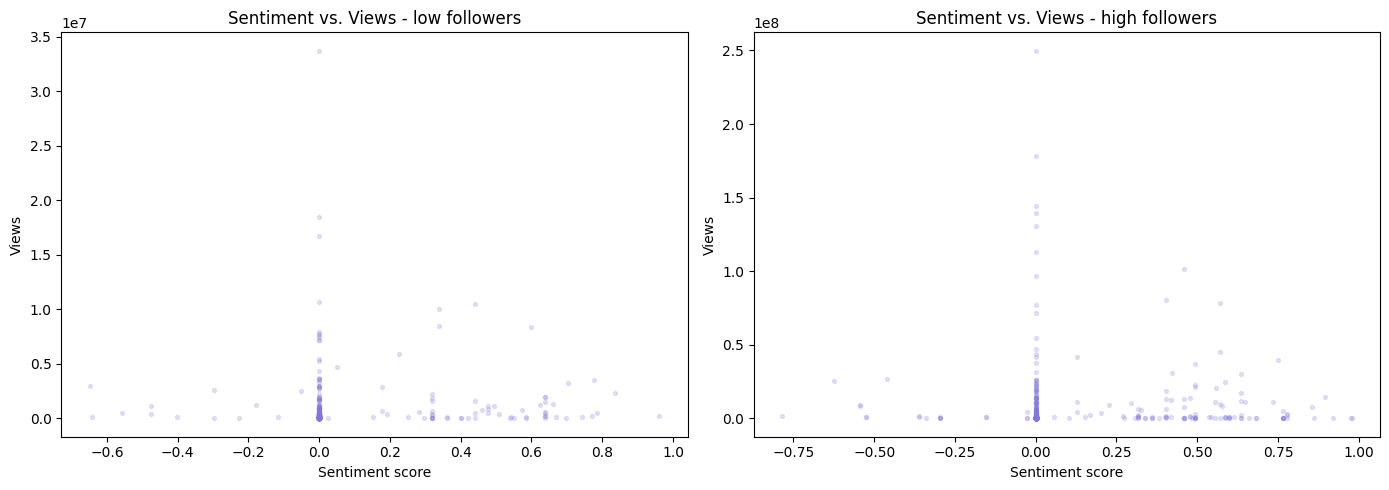

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tier in zip(axes, ["low followers", "high followers"]):
    subset = df[df["creator_tier"] == tier]
    ax.scatter(subset["sentiment"], subset["views"], alpha=0.2, s=8, color="#7F77DD")
    ax.set_title(f"Sentiment vs. Views - {tier}")
    ax.set_xlabel("Sentiment score")
    ax.set_ylabel("Views")

plt.tight_layout()
plt.show()

In [20]:
print("---- Most Positive Captions ----")
print(df.nlargest(5, "sentiment")[["text_part", "sentiment", "views"]].to_string())

print("\n---- Most Negative Captions ----")
print(df.nsmallest(5, "sentiment")[["text_part", "sentiment", "views"]].to_string())

---- Most Positive Captions ----
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              text_part  sentiment       views
71                                                                                      

In [21]:
df.to_csv("../data/processed/tiktok_sentiment.csv", index=False)
print("Saved to data/processed/tiktok_sentiment.csv")

Saved to data/processed/tiktok_sentiment.csv


In [22]:
## SENTIMENT ANALYSIS
- **Breakdown:** Percentage of captions are positive/neutral/negative
- **Engagement:** sentiment label gets movt views/likes
- **Correlation:** r value is positive/negative and if p < 0.05
- **Creator Level:** analyzes if sentiment matters more for small/large creators
- **Conclusion:** When analyzing caption sentiment, does it predict the engagement?

SyntaxError: illegal target for annotation (1314187026.py, line 2)